# 13 · Evaluación experimental final de la extensión híbrida multimodal

Este notebook evalúa la **extensión Pareto + KNN** construida en el notebook 12. Su objetivo no es repetir la evaluación del recomendador principal realizada en los notebooks 10 y 11, sino estudiar con más detalle el comportamiento de la capa KNN una vez integrada en el pipeline multimodal.

La unidad experimental es:

> **destino × modo de transporte × perfil de usuario**

y se mantienen los cuatro modos definidos en el sistema:

- `TRANSIT`
- `WALK`
- `BICYCLE`
- `CAR`

La evaluación se centra en cinco cuestiones:

1. cuánto mejora la eficiencia multiobjetivo al restringir KNN a la frontera de Pareto;
2. qué coste de similitud introduce esa restricción;
3. si el efecto cambia entre modos de transporte;
4. cuánto cambian los vecinos al modificar el perfil, el espacio de características o el número de vecinos `k`;
5. si todas estas conclusiones son reproducibles y coherentes con las salidas del notebook 12.

> **Criterio metodológico.** Que `Pareto_KNN` devuelva únicamente alternativas Pareto es una propiedad estructural del método, no una evidencia experimental. La parte empírica consiste en cuantificar qué recuperaría KNN sin esa restricción, cuánto cambia el conjunto de vecinos y cuánto aumenta la distancia de similitud al exigir eficiencia Pareto.


## 13.1 Librerías y configuración

Se emplean únicamente dependencias ya utilizadas en el proyecto. Para los intervalos de incertidumbre se utiliza **bootstrap no paramétrico**, evitando introducir supuestos de normalidad sobre las 36 combinaciones destino–modo–perfil.


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
BOOTSTRAP_ITERATIONS = 5000
CONFIDENCE_LEVEL = 0.95

EXPECTED_MODES = {"TRANSIT", "WALK", "BICYCLE", "CAR"}
EXPECTED_METHODS = {"KNN_global", "Pareto_KNN"}
EXPECTED_K_VALUES = {3, 5, 7, 10}
FLOAT_TOL = 1e-10


## 13.2 Localización del proyecto y contrato con el notebook 12

El notebook consume exclusivamente resultados ya generados por el 12. De esta forma, la evaluación queda desacoplada del cálculo de vecinos y puede reproducirse sin volver a reconstruir KNN.


In [2]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    required = (
        Path("data")
        / "results"
        / "knn12_multimodal_validation_report.csv"
    )

    for candidate in [current, *current.parents]:
        if (candidate / required).exists():
            return candidate

    raise FileNotFoundError(
        "No se ha localizado la raíz del proyecto. "
        "Ejecuta primero el notebook 12 y abre este cuaderno "
        "desde la carpeta del proyecto o desde notebooks/."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

INPUT_PATHS = {
    "validation": RESULTS_DIR / "knn12_multimodal_validation_report.csv",
    "anchors": RESULTS_DIR / "knn12_multimodal_anchors.csv",
    "availability": RESULTS_DIR / "knn12_multimodal_availability_audit.csv",
    "neighbors": RESULTS_DIR / "knn12_multimodal_neighbors_k5.csv",
    "evaluation": RESULTS_DIR / "knn12_multimodal_evaluation_k5.csv",
    "comparison": RESULTS_DIR / "knn12_multimodal_strategy_comparison.csv",
    "overlap": RESULTS_DIR / "knn12_multimodal_strategy_overlap.csv",
    "mode_summary": RESULTS_DIR / "knn12_multimodal_mode_summary.csv",
    "profile_overlap": RESULTS_DIR / "knn12_multimodal_profile_overlap.csv",
    "feature_overlap": RESULTS_DIR / "knn12_multimodal_feature_space_overlap.csv",
    "sensitivity": RESULTS_DIR / "knn12_multimodal_sensitivity_summary.csv",
    "empirical": RESULTS_DIR / "knn12_multimodal_empirical_indicators.csv",
    "summary12": RESULTS_DIR / "knn12_multimodal_summary.csv",
}

OUTPUT_PATHS = {
    "bootstrap": RESULTS_DIR / "evaluation13_multimodal_bootstrap_summary.csv",
    "mode_tradeoff": RESULTS_DIR / "evaluation13_multimodal_tradeoff_by_mode.csv",
    "profile": RESULTS_DIR / "evaluation13_multimodal_profile_differentiation.csv",
    "feature": RESULTS_DIR / "evaluation13_multimodal_feature_ablation.csv",
    "sensitivity": RESULTS_DIR / "evaluation13_multimodal_k_sensitivity.csv",
    "findings": RESULTS_DIR / "evaluation13_multimodal_empirical_findings.csv",
    "case_study": RESULTS_DIR / "evaluation13_multimodal_case_study.csv",
    "validation": RESULTS_DIR / "evaluation13_multimodal_validation_report.csv",
    "summary": RESULTS_DIR / "evaluation13_multimodal_summary.csv",
}

print("Raíz del proyecto:", PROJECT_ROOT)
print("Directorio de resultados:", RESULTS_DIR)


Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Directorio de resultados: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\results


## 13.3 Carga de resultados y comprobación del contrato

Antes de analizar resultados se comprueba que el notebook 12 terminó correctamente y que las tablas necesarias conservan la estructura esperada.


In [3]:
missing_paths = [
    path for path in INPUT_PATHS.values()
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Faltan resultados necesarios del notebook 12:\n"
        + "\n".join(
            f"- {path.relative_to(PROJECT_ROOT)}"
            for path in missing_paths
        )
    )

validation12 = pd.read_csv(INPUT_PATHS["validation"])
anchors = pd.read_csv(INPUT_PATHS["anchors"])
availability = pd.read_csv(INPUT_PATHS["availability"])
neighbors = pd.read_csv(INPUT_PATHS["neighbors"])
evaluation = pd.read_csv(INPUT_PATHS["evaluation"])
comparison = pd.read_csv(INPUT_PATHS["comparison"])
strategy_overlap = pd.read_csv(INPUT_PATHS["overlap"])
mode_summary12 = pd.read_csv(INPUT_PATHS["mode_summary"])
profile_overlap = pd.read_csv(INPUT_PATHS["profile_overlap"])
feature_overlap = pd.read_csv(INPUT_PATHS["feature_overlap"])
sensitivity = pd.read_csv(INPUT_PATHS["sensitivity"])
empirical12 = pd.read_csv(INPUT_PATHS["empirical"])
summary12 = pd.read_csv(INPUT_PATHS["summary12"], index_col=0)

print("Validaciones 12:", validation12.shape)
print("Escenarios ancla:", anchors.shape)
print("Vecinos k=5:", neighbors.shape)
print("Comparación de estrategias:", comparison.shape)
print("Sensibilidad a k:", sensitivity.shape)


Validaciones 12: (23, 5)
Escenarios ancla: (36, 15)
Vecinos k=5: (318, 26)
Comparación de estrategias: (36, 23)
Sensibilidad a k: (32, 9)


In [4]:
def coerce_bool_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "si": True,
        "sí": True,
        "false": False,
        "0": False,
        "no": False,
    }

    parsed = normalized.map(mapping)

    if parsed.isna().any():
        bad = sorted(
            series.loc[parsed.isna()].astype(str).unique().tolist()
        )
        raise ValueError(
            "No se ha podido interpretar una columna booleana. "
            f"Valores problemáticos: {bad[:10]}"
        )

    return parsed.astype(bool)


required_validation_columns = {
    "validation_id",
    "passed",
}

required_anchor_columns = {
    "destination_id",
    "destination_name",
    "transport_mode",
    "profile_id",
    "anchor_zone_key",
}

required_comparison_columns = {
    "destination_id",
    "transport_mode",
    "profile_id",
    "global_returned_neighbors",
    "hybrid_returned_neighbors",
    "global_pareto_rate_pct",
    "hybrid_pareto_rate_pct",
    "global_dominated_neighbors",
    "global_mean_distance",
    "hybrid_mean_distance",
    "pareto_gain_pp",
    "similarity_cost_absolute",
    "similarity_cost_pct",
}

required_overlap_columns = {
    "destination_id",
    "transport_mode",
    "profile_id",
    "jaccard",
}

required_profile_overlap_columns = {
    "destination_id",
    "transport_mode",
    "profile_a",
    "profile_b",
    "jaccard",
}

required_feature_overlap_columns = {
    "destination_id",
    "transport_mode",
    "profile_id",
    "method",
    "jaccard",
}

required_sensitivity_columns = {
    "transport_mode",
    "method",
    "requested_k",
    "scenarios",
    "mean_returned_neighbors",
    "mean_pareto_rate_pct",
    "mean_normalized_distance",
}

required_neighbor_columns = {
    "destination_id",
    "destination_name",
    "transport_mode",
    "profile_id",
    "method",
    "neighbor_rank",
    "anchor_zone_key",
    "anchor_neighborhood_name",
    "neighbor_zone_key",
    "neighbor_neighborhood_name",
    "neighbor_is_pareto",
    "normalized_knn_distance",
    "price_delta_pct",
    "time_delta_pct",
    "top_distance_drivers",
}

checks = {
    "validation12": required_validation_columns - set(validation12.columns),
    "anchors": required_anchor_columns - set(anchors.columns),
    "comparison": required_comparison_columns - set(comparison.columns),
    "strategy_overlap": required_overlap_columns - set(strategy_overlap.columns),
    "profile_overlap": required_profile_overlap_columns - set(profile_overlap.columns),
    "feature_overlap": required_feature_overlap_columns - set(feature_overlap.columns),
    "sensitivity": required_sensitivity_columns - set(sensitivity.columns),
    "neighbors": required_neighbor_columns - set(neighbors.columns),
}

problems = {
    name: sorted(columns)
    for name, columns in checks.items()
    if columns
}

if problems:
    raise KeyError(
        "Las salidas del notebook 12 no cumplen el contrato esperado: "
        f"{problems}"
    )

validation12["passed"] = coerce_bool_series(validation12["passed"])

if not validation12["passed"].all():
    failed = validation12.loc[~validation12["passed"]]
    display(failed)
    raise AssertionError(
        "El notebook 12 contiene validaciones estructurales no superadas."
    )

if "full_k_available" in availability.columns:
    availability["full_k_available"] = coerce_bool_series(
        availability["full_k_available"]
    )

if "neighbor_is_pareto" in neighbors.columns:
    neighbors["neighbor_is_pareto"] = coerce_bool_series(
        neighbors["neighbor_is_pareto"]
    )

for column in [
    "global_pareto_rate_pct",
    "hybrid_pareto_rate_pct",
    "global_dominated_neighbors",
    "global_mean_distance",
    "hybrid_mean_distance",
    "pareto_gain_pp",
    "similarity_cost_absolute",
    "similarity_cost_pct",
]:
    comparison[column] = pd.to_numeric(
        comparison[column],
        errors="coerce",
    )

strategy_overlap["jaccard"] = pd.to_numeric(
    strategy_overlap["jaccard"],
    errors="coerce",
)
profile_overlap["jaccard"] = pd.to_numeric(
    profile_overlap["jaccard"],
    errors="coerce",
)
feature_overlap["jaccard"] = pd.to_numeric(
    feature_overlap["jaccard"],
    errors="coerce",
)

for column in [
    "requested_k",
    "scenarios",
    "mean_returned_neighbors",
    "mean_pareto_rate_pct",
    "mean_normalized_distance",
]:
    sensitivity[column] = pd.to_numeric(
        sensitivity[column],
        errors="coerce",
    )

print(
    "Contrato del notebook 12 superado:",
    f"{int(validation12['passed'].sum())}/{len(validation12)}",
)


Contrato del notebook 12 superado: 23/23


## 13.4 Unidad experimental y cobertura multimodal

La comparación principal utiliza una fila por combinación **destino × modo × perfil**. Con tres destinos, cuatro modos y tres perfiles, el diseño actual debe producir 36 escenarios.


In [5]:
SCENARIO_KEY = [
    "destination_id",
    "transport_mode",
    "profile_id",
]

destinations = sorted(
    comparison["destination_id"].astype(str).unique()
)
modes = sorted(
    comparison["transport_mode"].astype(str).unique()
)
profiles = sorted(
    comparison["profile_id"].astype(str).unique()
)

expected_scenarios = (
    len(destinations)
    * len(modes)
    * len(profiles)
)

scenario_duplicates = int(
    comparison.duplicated(subset=SCENARIO_KEY).sum()
)

coverage_summary = pd.DataFrame(
    {
        "dimension": [
            "destinations",
            "transport_modes",
            "profiles",
            "expected_scenarios",
            "observed_scenarios",
            "duplicate_scenarios",
        ],
        "value": [
            len(destinations),
            len(modes),
            len(profiles),
            expected_scenarios,
            len(comparison),
            scenario_duplicates,
        ],
    }
)

display(coverage_summary)


,dimension,value
0,destinations,3
1,transport_modes,4
2,profiles,3
3,expected_scenarios,36
4,observed_scenarios,36
5,duplicate_scenarios,0


## 13.5 Trade-off entre eficiencia Pareto y similitud

Se comparan, escenario a escenario:

- **KNN global**, que busca los vecinos más similares sin imponer eficiencia multiobjetivo;
- **Pareto + KNN**, que restringe la búsqueda a alternativas no dominadas.

Las métricas centrales son:

- `pareto_gain_pp`: ganancia en puntos porcentuales de vecinos Pareto;
- `similarity_cost_absolute`: incremento de distancia normalizada al restringir la búsqueda;
- `similarity_cost_pct`: incremento relativo respecto a KNN global;
- `jaccard`: solapamiento entre los conjuntos de vecinos recuperados por ambos métodos.


In [6]:
tradeoff = comparison.merge(
    strategy_overlap[
        SCENARIO_KEY + ["jaccard"]
    ].rename(columns={"jaccard": "strategy_jaccard"}),
    on=SCENARIO_KEY,
    how="left",
    validate="one_to_one",
)

tradeoff["global_dominated_rate_pct"] = (
    100
    * tradeoff["global_dominated_neighbors"]
    / tradeoff["global_returned_neighbors"]
)

tradeoff_summary = pd.DataFrame(
    {
        "metric": [
            "global_pareto_rate_pct",
            "pareto_gain_pp",
            "similarity_cost_absolute",
            "similarity_cost_pct",
            "strategy_jaccard",
            "global_dominated_rate_pct",
        ],
        "mean": [
            tradeoff["global_pareto_rate_pct"].mean(),
            tradeoff["pareto_gain_pp"].mean(),
            tradeoff["similarity_cost_absolute"].mean(),
            tradeoff["similarity_cost_pct"].mean(),
            tradeoff["strategy_jaccard"].mean(),
            tradeoff["global_dominated_rate_pct"].mean(),
        ],
        "median": [
            tradeoff["global_pareto_rate_pct"].median(),
            tradeoff["pareto_gain_pp"].median(),
            tradeoff["similarity_cost_absolute"].median(),
            tradeoff["similarity_cost_pct"].median(),
            tradeoff["strategy_jaccard"].median(),
            tradeoff["global_dominated_rate_pct"].median(),
        ],
        "q25": [
            tradeoff["global_pareto_rate_pct"].quantile(0.25),
            tradeoff["pareto_gain_pp"].quantile(0.25),
            tradeoff["similarity_cost_absolute"].quantile(0.25),
            tradeoff["similarity_cost_pct"].quantile(0.25),
            tradeoff["strategy_jaccard"].quantile(0.25),
            tradeoff["global_dominated_rate_pct"].quantile(0.25),
        ],
        "q75": [
            tradeoff["global_pareto_rate_pct"].quantile(0.75),
            tradeoff["pareto_gain_pp"].quantile(0.75),
            tradeoff["similarity_cost_absolute"].quantile(0.75),
            tradeoff["similarity_cost_pct"].quantile(0.75),
            tradeoff["strategy_jaccard"].quantile(0.75),
            tradeoff["global_dominated_rate_pct"].quantile(0.75),
        ],
    }
)

display(tradeoff_summary)


,metric,mean,median,q25,q75
0,global_pareto_rate_pct,21.2963,20.0000,0.0000,33.3333
1,pareto_gain_pp,78.7037,80.0000,66.6667,100.0000
2,similarity_cost_absolute,0.3375,0.3337,0.2021,0.4895
3,similarity_cost_pct,74.2068,75.0096,38.4875,105.1547
4,strategy_jaccard,0.1420,0.1111,0.0000,0.2000
5,global_dominated_rate_pct,78.7037,80.0000,66.6667,100.0000


## 13.6 Incertidumbre mediante bootstrap pareado

Las 36 observaciones no representan usuarios independientes ni una muestra aleatoria de toda la población de Madrid. Por ello, los intervalos bootstrap se interpretan como una medida de **estabilidad descriptiva dentro del experimento**, no como inferencia poblacional.

El remuestreo es pareado porque cada fila ya contiene las dos estrategias evaluadas sobre el mismo destino, modo y perfil.


In [7]:
def bootstrap_mean_ci(
    values: pd.Series | np.ndarray,
    iterations: int = BOOTSTRAP_ITERATIONS,
    confidence_level: float = CONFIDENCE_LEVEL,
    seed: int = RANDOM_STATE,
) -> dict:
    array = pd.to_numeric(
        pd.Series(values),
        errors="coerce",
    ).dropna().to_numpy(dtype=float)

    if len(array) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    rng = np.random.default_rng(seed)
    sample_indices = rng.integers(
        0,
        len(array),
        size=(iterations, len(array)),
    )

    bootstrap_means = array[sample_indices].mean(axis=1)

    alpha = 1.0 - confidence_level
    low = 100 * (alpha / 2)
    high = 100 * (1 - alpha / 2)

    return {
        "n": len(array),
        "mean": float(array.mean()),
        "ci_low": float(np.percentile(bootstrap_means, low)),
        "ci_high": float(np.percentile(bootstrap_means, high)),
    }


bootstrap_metrics = {
    "pareto_gain_pp": tradeoff["pareto_gain_pp"],
    "similarity_cost_absolute": tradeoff["similarity_cost_absolute"],
    "similarity_cost_pct": tradeoff["similarity_cost_pct"],
    "strategy_jaccard": tradeoff["strategy_jaccard"],
    "global_dominated_rate_pct": tradeoff["global_dominated_rate_pct"],
}

bootstrap_rows = []

for metric, values in bootstrap_metrics.items():
    result = bootstrap_mean_ci(values)
    bootstrap_rows.append(
        {
            "metric": metric,
            **result,
            "confidence_level": CONFIDENCE_LEVEL,
            "iterations": BOOTSTRAP_ITERATIONS,
        }
    )

bootstrap_summary = pd.DataFrame(bootstrap_rows)
display(bootstrap_summary)


,metric,n,mean,ci_low,ci_high,confidence_level,iterations
0,pareto_gain_pp,36,78.7037,70.7407,85.9259,0.9500,5000
1,similarity_cost_absolute,36,0.3375,0.2853,0.3895,0.9500,5000
2,similarity_cost_pct,36,74.2068,61.5334,87.7558,0.9500,5000
3,strategy_jaccard,36,0.1420,0.0878,0.2074,0.9500,5000
4,global_dominated_rate_pct,36,78.7037,70.7407,85.9259,0.9500,5000


## 13.7 Resultados por modo de transporte

La comparación no mezcla modos dentro del cálculo de KNN. En esta sección se agregan posteriormente los resultados para comprobar si el coste de exigir eficiencia Pareto es homogéneo o varía entre `TRANSIT`, `WALK`, `BICYCLE` y `CAR`.


In [8]:
mode_tradeoff = (
    tradeoff.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_global_pareto_rate_pct=("global_pareto_rate_pct", "mean"),
        mean_pareto_gain_pp=("pareto_gain_pp", "mean"),
        mean_similarity_cost_absolute=("similarity_cost_absolute", "mean"),
        median_similarity_cost_pct=("similarity_cost_pct", "median"),
        mean_strategy_jaccard=("strategy_jaccard", "mean"),
        scenarios_with_dominated_global_neighbors=(
            "global_dominated_neighbors",
            lambda s: int((s > 0).sum()),
        ),
    )
)

mode_ci_rows = []

for mode, group in tradeoff.groupby("transport_mode", sort=True):
    cost_ci = bootstrap_mean_ci(
        group["similarity_cost_absolute"],
        seed=RANDOM_STATE,
    )
    gain_ci = bootstrap_mean_ci(
        group["pareto_gain_pp"],
        seed=RANDOM_STATE + 1,
    )

    mode_ci_rows.append(
        {
            "transport_mode": mode,
            "similarity_cost_ci_low": cost_ci["ci_low"],
            "similarity_cost_ci_high": cost_ci["ci_high"],
            "pareto_gain_ci_low": gain_ci["ci_low"],
            "pareto_gain_ci_high": gain_ci["ci_high"],
        }
    )

mode_tradeoff = mode_tradeoff.merge(
    pd.DataFrame(mode_ci_rows),
    on="transport_mode",
    how="left",
    validate="one_to_one",
)

display(mode_tradeoff)


,transport_mode,scenarios,mean_global_pareto_rate_pct,mean_pareto_gain_pp,mean_similarity_cost_absolute,median_similarity_cost_pct,mean_strategy_jaccard,scenarios_with_dominated_global_neighbors,similarity_cost_ci_low,similarity_cost_ci_high,pareto_gain_ci_low,pareto_gain_ci_high
0,BICYCLE,9,26.6667,73.3333,0.3321,84.1612,0.1778,9,0.2450,0.4128,57.7593,86.6667
1,CAR,9,15.5556,84.4444,0.3262,49.3189,0.0957,9,0.2383,0.4198,73.3333,95.5556
2,TRANSIT,9,24.4444,75.5556,0.3789,82.7334,0.1852,9,0.2622,0.4839,53.3333,93.3333
3,WALK,9,18.5185,81.4815,0.3127,43.4645,0.1093,9,0.2033,0.4333,71.8519,91.1111


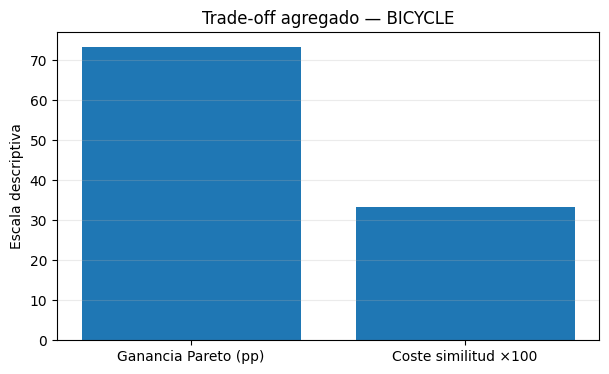

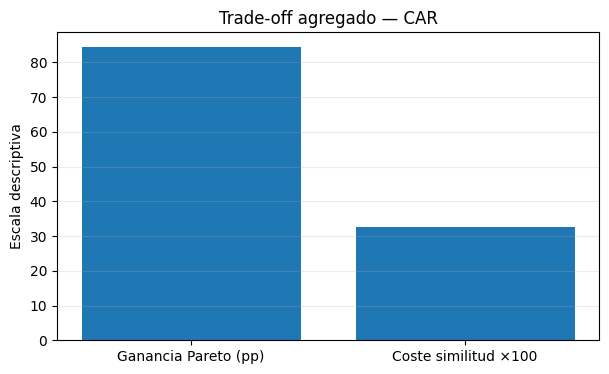

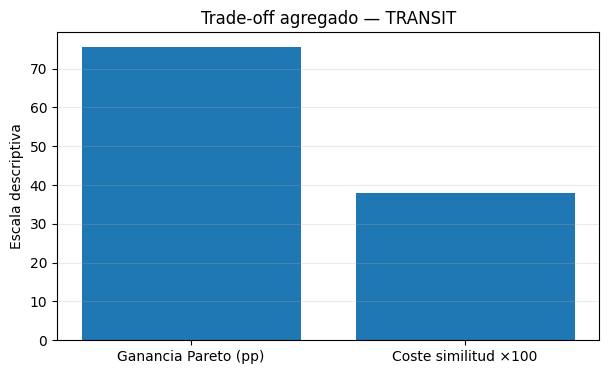

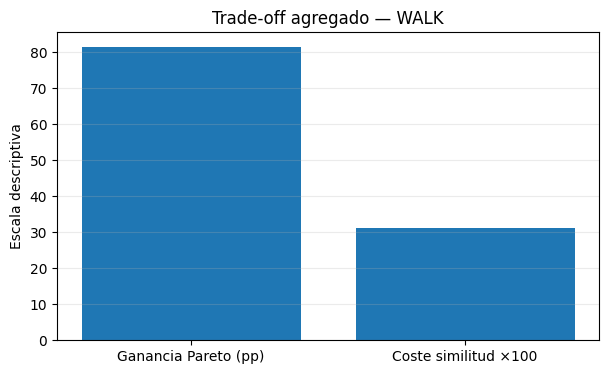

In [9]:
for mode in sorted(mode_tradeoff["transport_mode"]):
    row = mode_tradeoff.loc[
        mode_tradeoff["transport_mode"].eq(mode)
    ].iloc[0]

    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Ganancia Pareto (pp)", "Coste similitud ×100"],
        [
            row["mean_pareto_gain_pp"],
            100 * row["mean_similarity_cost_absolute"],
        ],
    )
    plt.title(f"Trade-off agregado — {mode}")
    plt.ylabel("Escala descriptiva")
    plt.grid(axis="y", alpha=0.25)
    plt.show()


> El gráfico utiliza dos magnitudes con unidades distintas y por eso se presenta únicamente como apoyo visual descriptivo. Las conclusiones cuantitativas se extraen de la tabla anterior, no de la altura relativa de las barras.


## 13.8 Diferenciación entre perfiles

El perfil del usuario determina la recomendación de referencia. Después, Pareto + KNN busca alternativas similares alrededor de esa referencia.

Se analiza el índice de Jaccard entre los conjuntos de vecinos de los tres perfiles. Valores próximos a 1 indican listas muy parecidas; valores bajos indican que las preferencias están generando alternativas diferentes.


In [10]:
profile_differentiation = (
    profile_overlap.groupby(
        [
            "transport_mode",
            "profile_a",
            "profile_b",
        ],
        as_index=False,
    )
    .agg(
        groups=("destination_id", "size"),
        mean_jaccard=("jaccard", "mean"),
        median_jaccard=("jaccard", "median"),
        min_jaccard=("jaccard", "min"),
        max_jaccard=("jaccard", "max"),
    )
)

anchor_diversity = (
    anchors.groupby(
        [
            "destination_id",
            "transport_mode",
        ],
        as_index=False,
    )
    .agg(
        profiles=("profile_id", "nunique"),
        unique_anchor_zones=("anchor_zone_key", "nunique"),
    )
)

profile_changed_groups = int(
    (anchor_diversity["unique_anchor_zones"] > 1).sum()
)

display(profile_differentiation)
display(anchor_diversity)

print(
    "Grupos destino-modo donde los perfiles cambian la referencia:",
    f"{profile_changed_groups}/{len(anchor_diversity)}",
)


,transport_mode,profile_a,profile_b,groups,mean_jaccard,median_jaccard,min_jaccard,max_jaccard
0,BICYCLE,balanced,price_priority,3,0.4259,0.5000,0.1111,0.6667
1,BICYCLE,balanced,time_priority,3,0.5000,0.2500,0.2500,1.0000
2,BICYCLE,price_priority,time_priority,3,0.2037,0.1111,0.0000,0.5000
3,CAR,balanced,price_priority,3,0.3466,0.4286,0.1111,0.5000
4,CAR,balanced,time_priority,3,0.4762,0.4286,0.0000,1.0000
5,CAR,price_priority,time_priority,3,0.2037,0.1111,0.0000,0.5000
6,TRANSIT,balanced,price_priority,3,0.4857,0.4286,0.4286,0.6000
7,TRANSIT,balanced,time_priority,3,1.0000,1.0000,1.0000,1.0000
8,TRANSIT,price_priority,time_priority,3,0.4857,0.4286,0.4286,0.6000
9,WALK,balanced,price_priority,3,0.3889,0.5000,0.0000,0.6667


,destination_id,transport_mode,profiles,unique_anchor_zones
0,DEST_001,BICYCLE,3,3
1,DEST_001,CAR,3,3
2,DEST_001,TRANSIT,3,2
3,DEST_001,WALK,3,3
4,DEST_002,BICYCLE,3,3
5,DEST_002,CAR,3,3
6,DEST_002,TRANSIT,3,2
7,DEST_002,WALK,3,3
8,DEST_003,BICYCLE,3,2
9,DEST_003,CAR,3,2


Grupos destino-modo donde los perfiles cambian la referencia: 12/12


## 13.9 Ablación del espacio de características

El notebook 12 compara dos representaciones:

- `objective_only`: precio y tiempo;
- `extended`: precio, tiempo y características residenciales disponibles con cobertura suficiente.

Aquí se resume cuánto cambia la lista de vecinos al utilizar la representación extendida. El objetivo no es afirmar que más variables sean siempre mejores, sino comprobar si añaden información suficiente como para modificar las alternativas recuperadas.


In [11]:
feature_ablation = (
    feature_overlap.groupby(
        [
            "transport_mode",
            "method",
        ],
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_jaccard=("jaccard", "mean"),
        median_jaccard=("jaccard", "median"),
        unchanged_lists=(
            "jaccard",
            lambda s: int(np.isclose(s, 1.0, atol=FLOAT_TOL).sum()),
        ),
    )
)

feature_ablation["changed_lists"] = (
    feature_ablation["scenarios"]
    - feature_ablation["unchanged_lists"]
)

feature_ablation["changed_lists_pct"] = (
    100
    * feature_ablation["changed_lists"]
    / feature_ablation["scenarios"]
)

display(feature_ablation)


,transport_mode,method,scenarios,mean_jaccard,median_jaccard,unchanged_lists,changed_lists,changed_lists_pct
0,BICYCLE,KNN_global,9,0.3063,0.2000,0,9,100.0000
1,BICYCLE,Pareto_KNN,9,0.6521,0.6667,3,6,66.6667
2,CAR,KNN_global,9,0.1433,0.1111,0,9,100.0000
3,CAR,Pareto_KNN,9,0.7725,1.0000,5,4,44.4444
4,TRANSIT,KNN_global,9,0.1922,0.1429,0,9,100.0000
5,TRANSIT,Pareto_KNN,9,0.7989,1.0000,5,4,44.4444
6,WALK,KNN_global,9,0.3293,0.4286,0,9,100.0000
7,WALK,Pareto_KNN,9,0.6058,0.4286,3,6,66.6667


## 13.10 Sensibilidad al número de vecinos

Se utilizan los valores `k = 3, 5, 7, 10` ya calculados en el notebook 12. El objetivo es comprobar si las conclusiones dependen de un único valor de `k`.

En Pareto + KNN, la tasa Pareto debe permanecer en 100 % por construcción. Lo relevante es observar cómo evoluciona la distancia media a medida que se solicitan más alternativas.


In [12]:
k_sensitivity = sensitivity.copy()

k_sensitivity = k_sensitivity.sort_values(
    [
        "transport_mode",
        "method",
        "requested_k",
    ]
).reset_index(drop=True)

display(k_sensitivity)


,transport_mode,method,requested_k,scenarios,mean_returned_neighbors,mean_pareto_rate_pct,mean_normalized_distance,mean_abs_price_change_pct,mean_abs_time_change_pct
0,BICYCLE,KNN_global,3,9,3.0000,25.9259,0.4225,23.5736,80.6926
1,BICYCLE,KNN_global,5,9,4.3333,26.6667,0.4582,22.4761,102.8071
2,BICYCLE,KNN_global,7,9,5.6667,22.2222,0.4836,23.4598,119.7347
3,BICYCLE,KNN_global,10,9,7.6667,22.2222,0.5119,23.6784,133.0278
4,BICYCLE,Pareto_KNN,3,9,3.0000,100.0000,0.7203,31.2785,94.1860
5,BICYCLE,Pareto_KNN,5,9,4.3333,100.0000,0.7903,34.9965,132.3404
6,BICYCLE,Pareto_KNN,7,9,5.6667,100.0000,0.8543,38.0643,159.3732
7,BICYCLE,Pareto_KNN,10,9,7.6667,100.0000,0.9394,42.1785,181.3155
8,CAR,KNN_global,3,9,3.0000,14.8148,0.4337,19.1290,35.8091
9,CAR,KNN_global,5,9,4.3333,15.5556,0.4625,20.2867,38.5946


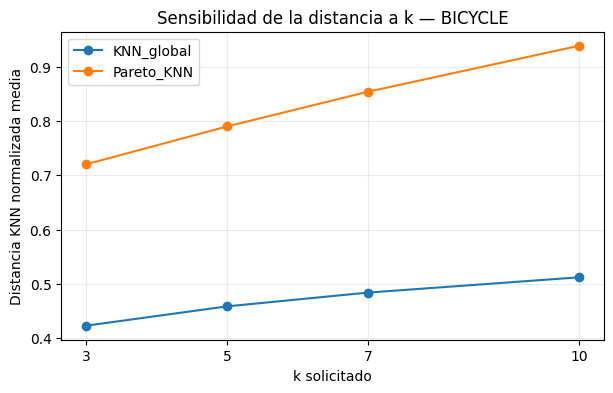

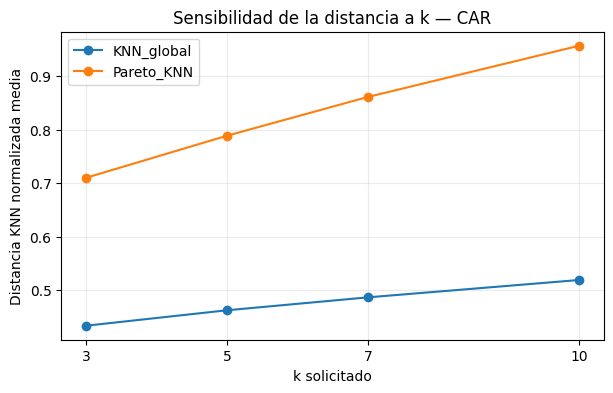

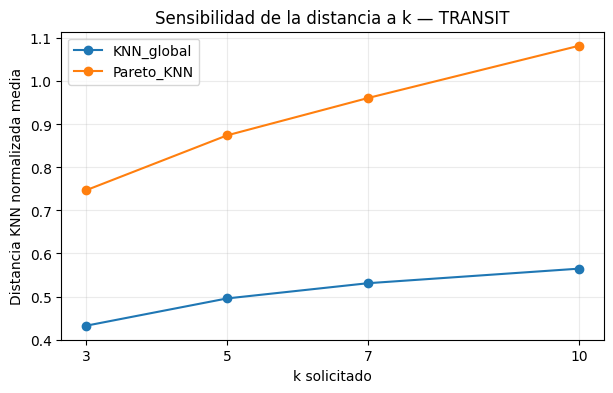

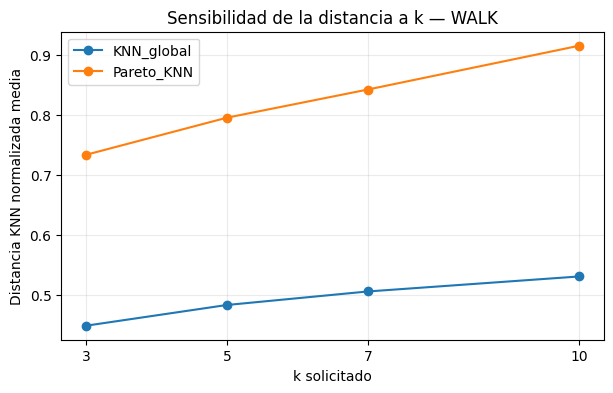

In [13]:
for mode in sorted(k_sensitivity["transport_mode"].unique()):
    plot_data = k_sensitivity.loc[
        k_sensitivity["transport_mode"].eq(mode)
    ]

    plt.figure(figsize=(7, 4))

    for method, method_group in plot_data.groupby("method", sort=True):
        method_group = method_group.sort_values("requested_k")
        plt.plot(
            method_group["requested_k"],
            method_group["mean_normalized_distance"],
            marker="o",
            label=method,
        )

    plt.title(f"Sensibilidad de la distancia a k — {mode}")
    plt.xlabel("k solicitado")
    plt.ylabel("Distancia KNN normalizada media")
    plt.xticks(sorted(plot_data["requested_k"].unique()))
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


## 13.11 Disponibilidad de vecinos

Un frente de Pareto puede ser pequeño. Por eso, el notebook 12 compara ambas estrategias con el mismo `comparison_k`, aunque sea inferior al `k` solicitado.

Esta sección cuantifica cuántos escenarios pueden devolver los cinco vecinos completos y en cuáles el frente limita el número de alternativas.


In [14]:
availability_summary = (
    availability.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_global_candidates=("global_candidates", "mean"),
        mean_pareto_candidates=("pareto_candidates", "mean"),
        mean_comparison_k=("comparison_k", "mean"),
        full_k_scenarios=(
            "full_k_available",
            lambda s: int(pd.Series(s).astype(bool).sum()),
        ),
    )
)

availability_summary["full_k_rate_pct"] = (
    100
    * availability_summary["full_k_scenarios"]
    / availability_summary["scenarios"]
)

display(availability_summary)


,transport_mode,scenarios,mean_global_candidates,mean_pareto_candidates,mean_comparison_k,full_k_scenarios,full_k_rate_pct
0,BICYCLE,9,128.0000,10.3333,4.3333,6,66.6667
1,CAR,9,120.0000,11.0000,4.3333,6,66.6667
2,TRANSIT,9,122.6667,8.3333,4.6667,6,66.6667
3,WALK,9,111.0000,11.6667,4.3333,6,66.6667


## 13.12 Caso representativo e interpretación de vecinos

Para evitar seleccionar manualmente un ejemplo favorable, se toma el escenario cuya `similarity_cost_absolute` está más cerca de la mediana global. Así se muestra un caso representativo del comportamiento observado.


In [15]:
median_cost = tradeoff["similarity_cost_absolute"].median()

representative_idx = (
    (tradeoff["similarity_cost_absolute"] - median_cost)
    .abs()
    .idxmin()
)

representative = tradeoff.loc[representative_idx]

case_mask = (
    neighbors["destination_id"].astype(str).eq(
        str(representative["destination_id"])
    )
    & neighbors["transport_mode"].astype(str).eq(
        str(representative["transport_mode"])
    )
    & neighbors["profile_id"].astype(str).eq(
        str(representative["profile_id"])
    )
)

case_study = (
    neighbors.loc[
        case_mask,
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "profile_id",
            "method",
            "neighbor_rank",
            "anchor_zone_key",
            "anchor_neighborhood_name",
            "neighbor_zone_key",
            "neighbor_neighborhood_name",
            "neighbor_is_pareto",
            "normalized_knn_distance",
            "price_delta_pct",
            "time_delta_pct",
            "top_distance_drivers",
        ],
    ]
    .sort_values(["method", "neighbor_rank"])
    .reset_index(drop=True)
)

display(
    Markdown(
        f"""
### Escenario representativo

- **Destino:** {representative['destination_id']}
- **Modo:** {representative['transport_mode']}
- **Perfil:** {representative['profile_id']}
- **Coste de similitud:** {representative['similarity_cost_absolute']:.4f}
- **Ganancia Pareto:** {representative['pareto_gain_pp']:.2f} pp
- **Jaccard entre estrategias:** {representative['strategy_jaccard']:.3f}
"""
    )
)

display(case_study)



### Escenario representativo

- **Destino:** DEST_001
- **Modo:** WALK
- **Perfil:** time_priority
- **Coste de similitud:** 0.3335
- **Ganancia Pareto:** 80.00 pp
- **Jaccard entre estrategias:** 0.111


,destination_id,destination_name,transport_mode,profile_id,method,neighbor_rank,anchor_zone_key,anchor_neighborhood_name,neighbor_zone_key,neighbor_neighborhood_name,neighbor_is_pareto,normalized_knn_distance,price_delta_pct,time_delta_pct,top_distance_drivers
0,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,1,MAD-016,Sol,MAD-013,Cortes,True,0.2660,-5.8449,472.0721,exterior_ratio (45.5 %); elevator_ratio (26.6 ...
1,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,2,MAD-016,Sol,MAD-015,Universidad,False,0.5208,-7.2913,780.1802,exterior_ratio (84.2 %); commute_daily_minutes...
2,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,3,MAD-016,Sol,MAD-014,Justicia,False,0.5368,23.9754,854.5045,price_m2_for_recommender (50.4 %); elevator_ra...
3,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,4,MAD-016,Sol,MAD-092,Argüelles,False,0.6069,-1.8416,"1,323.4234",elevator_ratio (52.9 %); exterior_ratio (17.6 ...
4,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,5,MAD-016,Sol,MAD-027,Atocha,False,0.6365,-11.5148,"2,360.8108",commute_daily_minutes (45.8 %); elevator_ratio...
5,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,1,MAD-016,Sol,MAD-013,Cortes,True,0.2660,-5.8449,472.0721,exterior_ratio (45.5 %); elevator_ratio (26.6 ...
6,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,2,MAD-016,Sol,MAD-023,Chopera,True,0.8898,-28.8793,"2,000.9009",elevator_ratio (48.2 %); price_m2_for_recommen...
7,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,3,MAD-016,Sol,MAD-102,Puerta del Ángel,True,0.9751,-47.5964,"2,054.5045",price_m2_for_recommender (60.2 %); elevator_ra...
8,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,4,MAD-016,Sol,MAD-125,Moscardó,True,0.9989,-51.4178,"2,623.4234",price_m2_for_recommender (67.0 %); commute_dai...
9,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,5,MAD-016,Sol,MAD-112,Opañel,True,1.1050,-54.5139,"2,740.9910",price_m2_for_recommender (61.5 %); commute_dai...


## 13.13 Hallazgos empíricos

Los siguientes resultados se presentan como **hallazgos descriptivos**, no como contratos estructurales ni como métricas de precisión predictiva.

No existe una etiqueta de “barrio correcto” obtenida de usuarios reales, por lo que no procede utilizar *accuracy*, MAE o R² para evaluar KNN en este contexto.


In [16]:
scenarios_with_dominated = int(
    (tradeoff["global_dominated_neighbors"] > 0).sum()
)

global_dominated_share = (
    100 * scenarios_with_dominated / len(tradeoff)
)

mean_profile_jaccard = float(
    profile_overlap["jaccard"].mean()
)

mean_feature_jaccard = float(
    feature_overlap["jaccard"].mean()
)

mean_strategy_jaccard = float(
    tradeoff["strategy_jaccard"].mean()
)

full_k_total = int(
    availability["full_k_available"].astype(bool).sum()
)

full_k_rate = (
    100 * full_k_total / len(availability)
)

findings = pd.DataFrame(
    [
        {
            "finding_id": "F1",
            "finding": (
                "KNN global recupera alternativas dominadas "
                "en parte de los escenarios."
            ),
            "value": global_dominated_share,
            "unit": "% de escenarios",
            "evidence": (
                f"{scenarios_with_dominated}/{len(tradeoff)} escenarios"
            ),
        },
        {
            "finding_id": "F2",
            "finding": (
                "Exigir Pareto aumenta la distancia media de similitud."
            ),
            "value": tradeoff["similarity_cost_absolute"].mean(),
            "unit": "distancia normalizada",
            "evidence": (
                "Media de la diferencia Pareto_KNN - KNN_global."
            ),
        },
        {
            "finding_id": "F3",
            "finding": (
                "Las dos estrategias recuperan conjuntos de vecinos "
                "parcialmente diferentes."
            ),
            "value": mean_strategy_jaccard,
            "unit": "Jaccard medio",
            "evidence": (
                "Solapamiento de vecinos por destino-modo-perfil."
            ),
        },
        {
            "finding_id": "F4",
            "finding": (
                "Los perfiles de usuario producen conjuntos "
                "de vecinos diferenciados."
            ),
            "value": mean_profile_jaccard,
            "unit": "Jaccard medio",
            "evidence": (
                f"{profile_changed_groups}/{len(anchor_diversity)} "
                "grupos cambian además la referencia principal."
            ),
        },
        {
            "finding_id": "F5",
            "finding": (
                "El espacio extendido modifica las listas respecto "
                "a utilizar solo precio y tiempo."
            ),
            "value": mean_feature_jaccard,
            "unit": "Jaccard medio",
            "evidence": (
                "Ablación objective_only frente a extended."
            ),
        },
        {
            "finding_id": "F6",
            "finding": (
                "El frente Pareto permite devolver k=5 completo "
                "en una parte de los escenarios."
            ),
            "value": full_k_rate,
            "unit": "% de escenarios",
            "evidence": (
                f"{full_k_total}/{len(availability)} escenarios"
            ),
        },
    ]
)

display(findings)


,finding_id,finding,value,unit,evidence
0,F1,KNN global recupera alternativas dominadas en ...,100.0000,% de escenarios,36/36 escenarios
1,F2,Exigir Pareto aumenta la distancia media de si...,0.3375,distancia normalizada,Media de la diferencia Pareto_KNN - KNN_global.
2,F3,Las dos estrategias recuperan conjuntos de vec...,0.1420,Jaccard medio,Solapamiento de vecinos por destino-modo-perfil.
3,F4,Los perfiles de usuario producen conjuntos de ...,0.4250,Jaccard medio,12/12 grupos cambian además la referencia prin...
4,F5,El espacio extendido modifica las listas respe...,0.4751,Jaccard medio,Ablación objective_only frente a extended.
5,F6,El frente Pareto permite devolver k=5 completo...,66.6667,% de escenarios,24/36 escenarios


## 13.14 Validaciones estructurales

Estas validaciones comprueban integridad, reproducibilidad y coherencia entre archivos. No convierten los hallazgos empíricos anteriores en condiciones de aprobado/suspenso.


In [17]:
validation_rows = []


def add_validation(
    validation_id: str,
    description: str,
    passed: bool,
    detail: str,
) -> None:
    validation_rows.append(
        {
            "validation_id": validation_id,
            "validation_type": "structural",
            "description": description,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_validation(
    "notebook12_contract",
    "Todas las validaciones estructurales del notebook 12 están superadas.",
    validation12["passed"].all(),
    f"Superadas: {int(validation12['passed'].sum())}/{len(validation12)}",
)

add_validation(
    "exact_transport_modes",
    "Están presentes exactamente los cuatro modos del sistema.",
    set(modes) == EXPECTED_MODES,
    f"Modos: {modes}",
)

add_validation(
    "scenario_matrix_complete",
    "La matriz destino-modo-perfil está completa.",
    len(comparison) == expected_scenarios,
    f"Esperados: {expected_scenarios}; presentes: {len(comparison)}",
)

add_validation(
    "unique_scenarios",
    "No hay escenarios destino-modo-perfil duplicados.",
    scenario_duplicates == 0,
    f"Duplicados: {scenario_duplicates}",
)

missing_core = int(
    tradeoff[
        [
            "global_pareto_rate_pct",
            "hybrid_pareto_rate_pct",
            "global_mean_distance",
            "hybrid_mean_distance",
            "pareto_gain_pp",
            "similarity_cost_absolute",
            "strategy_jaccard",
        ]
    ].isna().any(axis=1).sum()
)

add_validation(
    "complete_core_metrics",
    "Las métricas principales están completas.",
    missing_core == 0,
    f"Filas incompletas: {missing_core}",
)

add_validation(
    "hybrid_is_pareto",
    "Pareto_KNN devuelve 100 % de vecinos Pareto por construcción.",
    np.allclose(
        comparison["hybrid_pareto_rate_pct"],
        100.0,
        atol=1e-9,
    ),
    (
        f"Mínimo observado: "
        f"{comparison['hybrid_pareto_rate_pct'].min():.4f}%"
    ),
)

add_validation(
    "fair_neighbor_count",
    "Las dos estrategias se comparan con el mismo número de vecinos.",
    (
        comparison["global_returned_neighbors"]
        == comparison["hybrid_returned_neighbors"]
    ).all(),
    (
        "Escenarios desiguales: "
        f"{int((comparison['global_returned_neighbors'] != comparison['hybrid_returned_neighbors']).sum())}"
    ),
)

add_validation(
    "nonnegative_similarity_cost",
    "La restricción a un subconjunto Pareto no reduce artificialmente la distancia media.",
    (comparison["similarity_cost_absolute"] >= -FLOAT_TOL).all(),
    (
        "Mínimo: "
        f"{comparison['similarity_cost_absolute'].min():.12f}"
    ),
)

add_validation(
    "nonnegative_pareto_gain",
    "La restricción Pareto no reduce la proporción de vecinos eficientes.",
    (comparison["pareto_gain_pp"] >= -FLOAT_TOL).all(),
    (
        "Mínimo: "
        f"{comparison['pareto_gain_pp'].min():.8f} pp"
    ),
)


def bounded_zero_one(series: pd.Series) -> bool:
    values = pd.to_numeric(series, errors="coerce")
    return bool(
        values.notna().all()
        and (values >= -FLOAT_TOL).all()
        and (values <= 1 + FLOAT_TOL).all()
    )


add_validation(
    "strategy_jaccard_bounds",
    "Los Jaccard entre estrategias están en [0, 1].",
    bounded_zero_one(strategy_overlap["jaccard"]),
    (
        f"Rango: {strategy_overlap['jaccard'].min():.4f}–"
        f"{strategy_overlap['jaccard'].max():.4f}"
    ),
)

add_validation(
    "profile_jaccard_bounds",
    "Los Jaccard entre perfiles están en [0, 1].",
    bounded_zero_one(profile_overlap["jaccard"]),
    (
        f"Rango: {profile_overlap['jaccard'].min():.4f}–"
        f"{profile_overlap['jaccard'].max():.4f}"
    ),
)

add_validation(
    "feature_jaccard_bounds",
    "Los Jaccard de la ablación están en [0, 1].",
    bounded_zero_one(feature_overlap["jaccard"]),
    (
        f"Rango: {feature_overlap['jaccard'].min():.4f}–"
        f"{feature_overlap['jaccard'].max():.4f}"
    ),
)

anchor_duplicates = int(
    anchors.duplicated(
        subset=[
            "destination_id",
            "transport_mode",
            "profile_id",
        ]
    ).sum()
)

add_validation(
    "unique_anchors",
    "Existe como máximo una referencia por destino-modo-perfil.",
    anchor_duplicates == 0,
    f"Duplicados: {anchor_duplicates}",
)

add_validation(
    "anchor_coverage",
    "Existe una referencia para cada escenario experimental.",
    len(anchors) == expected_scenarios,
    f"Esperadas: {expected_scenarios}; presentes: {len(anchors)}",
)

add_validation(
    "evaluation_methods",
    "La evaluación contiene exactamente KNN_global y Pareto_KNN.",
    set(evaluation["method"].astype(str).unique()) == EXPECTED_METHODS,
    f"Métodos: {sorted(evaluation['method'].astype(str).unique())}",
)

expected_evaluation_rows = expected_scenarios * len(EXPECTED_METHODS)

add_validation(
    "paired_evaluation_coverage",
    "Cada escenario tiene una fila de evaluación por estrategia.",
    len(evaluation) == expected_evaluation_rows,
    (
        f"Esperadas: {expected_evaluation_rows}; "
        f"presentes: {len(evaluation)}"
    ),
)

observed_k_values = set(
    pd.to_numeric(
        sensitivity["requested_k"],
        errors="coerce",
    ).dropna().astype(int)
)

add_validation(
    "sensitivity_k_values",
    "La sensibilidad cubre k = 3, 5, 7 y 10.",
    observed_k_values == EXPECTED_K_VALUES,
    f"k observados: {sorted(observed_k_values)}",
)

add_validation(
    "sensitivity_modes",
    "La sensibilidad cubre los cuatro modos.",
    set(sensitivity["transport_mode"].astype(str)) == EXPECTED_MODES,
    (
        "Modos: "
        f"{sorted(sensitivity['transport_mode'].astype(str).unique())}"
    ),
)

add_validation(
    "sensitivity_methods",
    "La sensibilidad cubre ambas estrategias.",
    set(sensitivity["method"].astype(str)) == EXPECTED_METHODS,
    (
        "Métodos: "
        f"{sorted(sensitivity['method'].astype(str).unique())}"
    ),
)

hybrid_sensitivity = sensitivity.loc[
    sensitivity["method"].astype(str).eq("Pareto_KNN")
]

add_validation(
    "hybrid_pareto_across_k",
    "Pareto_KNN conserva 100 % de vecinos Pareto para todos los k.",
    np.allclose(
        hybrid_sensitivity["mean_pareto_rate_pct"],
        100.0,
        atol=1e-9,
    ),
    (
        "Mínimo: "
        f"{hybrid_sensitivity['mean_pareto_rate_pct'].min():.4f}%"
    ),
)

add_validation(
    "mode_summary_coverage",
    "El resumen por modo contiene una fila para cada modo.",
    (
        len(mode_tradeoff) == len(EXPECTED_MODES)
        and set(mode_tradeoff["transport_mode"]) == EXPECTED_MODES
    ),
    f"Filas: {len(mode_tradeoff)}",
)

bootstrap_repeat = bootstrap_mean_ci(
    tradeoff["similarity_cost_absolute"],
    seed=RANDOM_STATE,
)

bootstrap_original = bootstrap_summary.loc[
    bootstrap_summary["metric"].eq("similarity_cost_absolute")
].iloc[0]

bootstrap_deterministic = (
    np.isclose(
        bootstrap_repeat["mean"],
        bootstrap_original["mean"],
        atol=1e-12,
    )
    and np.isclose(
        bootstrap_repeat["ci_low"],
        bootstrap_original["ci_low"],
        atol=1e-12,
    )
    and np.isclose(
        bootstrap_repeat["ci_high"],
        bootstrap_original["ci_high"],
        atol=1e-12,
    )
)

add_validation(
    "bootstrap_determinism",
    "El bootstrap es reproducible con la semilla fijada.",
    bootstrap_deterministic,
    f"Iteraciones: {BOOTSTRAP_ITERATIONS}",
)

validation_report = pd.DataFrame(validation_rows)
display(validation_report)

failed_validations = validation_report.loc[
    ~validation_report["passed"]
]

if not failed_validations.empty:
    display(Markdown("### Validaciones no superadas"))
    display(failed_validations)
    raise AssertionError(
        "El notebook 13 no ha superado todas "
        "las validaciones estructurales."
    )

print(
    "Todas las validaciones estructurales "
    "del notebook 13 se han superado correctamente."
)


,validation_id,validation_type,description,passed,detail
0,notebook12_contract,structural,Todas las validaciones estructurales del noteb...,True,Superadas: 23/23
1,exact_transport_modes,structural,Están presentes exactamente los cuatro modos d...,True,"Modos: ['BICYCLE', 'CAR', 'TRANSIT', 'WALK']"
2,scenario_matrix_complete,structural,La matriz destino-modo-perfil está completa.,True,Esperados: 36; presentes: 36
3,unique_scenarios,structural,No hay escenarios destino-modo-perfil duplicados.,True,Duplicados: 0
4,complete_core_metrics,structural,Las métricas principales están completas.,True,Filas incompletas: 0
5,hybrid_is_pareto,structural,Pareto_KNN devuelve 100 % de vecinos Pareto po...,True,Mínimo observado: 100.0000%
6,fair_neighbor_count,structural,Las dos estrategias se comparan con el mismo n...,True,Escenarios desiguales: 0
7,nonnegative_similarity_cost,structural,La restricción a un subconjunto Pareto no redu...,True,Mínimo: 0.085939866616
8,nonnegative_pareto_gain,structural,La restricción Pareto no reduce la proporción ...,True,Mínimo: 20.00000000 pp
9,strategy_jaccard_bounds,structural,"Los Jaccard entre estrategias están en [0, 1].",True,Rango: 0.0000–0.6667


Todas las validaciones estructurales del notebook 13 se han superado correctamente.


## 13.15 Síntesis para la memoria

La tabla final reúne resultados empíricos y validaciones, manteniendo separados ambos conceptos.


In [18]:
overall_summary = pd.Series(
    {
        "destinations": len(destinations),
        "transport_modes": len(modes),
        "profiles": len(profiles),
        "experimental_scenarios": len(tradeoff),
        "scenarios_with_dominated_global_neighbors": scenarios_with_dominated,
        "scenarios_with_dominated_global_neighbors_pct": global_dominated_share,
        "mean_global_pareto_rate_pct": tradeoff["global_pareto_rate_pct"].mean(),
        "mean_pareto_gain_pp": tradeoff["pareto_gain_pp"].mean(),
        "mean_similarity_cost_absolute": tradeoff["similarity_cost_absolute"].mean(),
        "median_similarity_cost_pct": tradeoff["similarity_cost_pct"].median(),
        "mean_strategy_jaccard": mean_strategy_jaccard,
        "mean_profile_jaccard": mean_profile_jaccard,
        "mean_feature_space_jaccard": mean_feature_jaccard,
        "groups_with_profile_dependent_anchor": profile_changed_groups,
        "destination_mode_groups": len(anchor_diversity),
        "full_k5_scenarios": full_k_total,
        "full_k5_rate_pct": full_k_rate,
        "structural_validations_passed": int(validation_report["passed"].sum()),
        "structural_validations_total": len(validation_report),
    },
    name="value",
).to_frame()

display(overall_summary)


,value
destinations,3.0000
transport_modes,4.0000
profiles,3.0000
experimental_scenarios,36.0000
scenarios_with_dominated_global_neighbors,36.0000
scenarios_with_dominated_global_neighbors_pct,100.0000
mean_global_pareto_rate_pct,21.2963
mean_pareto_gain_pp,78.7037
mean_similarity_cost_absolute,0.3375
median_similarity_cost_pct,75.0096


## 13.16 Exportación reproducible

Las salidas se guardan con el prefijo `evaluation13_multimodal_` para no sobrescribir los resultados experimentales de los notebooks anteriores.


In [19]:
EXPORTS = {
    OUTPUT_PATHS["bootstrap"]: bootstrap_summary,
    OUTPUT_PATHS["mode_tradeoff"]: mode_tradeoff,
    OUTPUT_PATHS["profile"]: profile_differentiation,
    OUTPUT_PATHS["feature"]: feature_ablation,
    OUTPUT_PATHS["sensitivity"]: k_sensitivity,
    OUTPUT_PATHS["findings"]: findings,
    OUTPUT_PATHS["case_study"]: case_study,
    OUTPUT_PATHS["validation"]: validation_report,
    OUTPUT_PATHS["summary"]: overall_summary,
}

for path, frame in EXPORTS.items():
    frame.to_csv(
        path,
        index=(path == OUTPUT_PATHS["summary"]),
        encoding="utf-8-sig",
    )

missing_exports = [
    path for path in EXPORTS
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado todos los resultados del notebook 13: "
        f"{missing_exports}"
    )

print("Archivos generados correctamente:")

for path in EXPORTS:
    print("-", path.relative_to(PROJECT_ROOT))


Archivos generados correctamente:
- data\results\evaluation13_multimodal_bootstrap_summary.csv
- data\results\evaluation13_multimodal_tradeoff_by_mode.csv
- data\results\evaluation13_multimodal_profile_differentiation.csv
- data\results\evaluation13_multimodal_feature_ablation.csv
- data\results\evaluation13_multimodal_k_sensitivity.csv
- data\results\evaluation13_multimodal_empirical_findings.csv
- data\results\evaluation13_multimodal_case_study.csv
- data\results\evaluation13_multimodal_validation_report.csv
- data\results\evaluation13_multimodal_summary.csv


## 13.17 Limitaciones

Esta evaluación debe interpretarse dentro del alcance real del TFG:

- KNN se utiliza como **método de similitud**, no como predictor supervisado.
- No existen etiquetas de satisfacción de usuarios reales, por lo que no puede afirmarse que un vecino sea “correcto” en sentido predictivo.
- La frontera de Pareto garantiza eficiencia únicamente respecto a los dos objetivos considerados: precio y tiempo.
- La distancia KNN depende de las variables disponibles y de su estandarización dentro de cada destino–modo.
- La comparación entre modos se realiza sobre métricas agregadas; las distancias KNN se calculan dentro de cada grupo y no constituyen una escala física universal.
- Los intervalos bootstrap describen estabilidad del experimento actual y no deben interpretarse como intervalos de confianza poblacionales sobre todos los posibles usuarios.
- Un frente Pareto pequeño puede limitar el número de vecinos disponibles; por eso ambas estrategias se comparan con el mismo `comparison_k`.


## 13.18 Conclusión

El notebook 13 cierra la evaluación de la extensión híbrida sin duplicar la evaluación del recomendador principal.

La aportación del análisis es cuantificar el compromiso entre dos propiedades distintas:

- **similitud**, proporcionada por KNN;
- **eficiencia multiobjetivo**, garantizada al restringir los candidatos a la frontera de Pareto.

El análisis se realiza por destino, modo de transporte y perfil de usuario, manteniendo la multimodalidad incorporada desde el notebook 06. La sensibilidad a `k`, la ablación del espacio de características, la diferenciación entre perfiles, los resultados por modo y el bootstrap pareado permiten evaluar la extensión desde varios ángulos sin atribuir a KNN una capacidad predictiva que no tiene.

Si las validaciones estructurales se superan, los resultados de este notebook pueden utilizarse como cierre experimental de la extensión Pareto + KNN y como evidencia cuantitativa para la memoria del TFG.


In [20]:
display(
    Markdown(
        f"""
### Resultado final

**Todas las validaciones estructurales del notebook 13 se han superado correctamente.**

Se han evaluado **{len(tradeoff)} escenarios destino–modo–perfil**, correspondientes a **{len(destinations)} destinos**, **{len(modes)} modos de transporte** y **{len(profiles)} perfiles**.

El análisis compara KNN global y Pareto + KNN, cuantifica el coste de similitud, estudia sensibilidad a `k`, perfiles, características y modos, e incorpora incertidumbre descriptiva mediante bootstrap.

**Notebook 13 multimodal finalizado correctamente.**
"""
    )
)



### Resultado final

**Todas las validaciones estructurales del notebook 13 se han superado correctamente.**

Se han evaluado **36 escenarios destino–modo–perfil**, correspondientes a **3 destinos**, **4 modos de transporte** y **3 perfiles**.

El análisis compara KNN global y Pareto + KNN, cuantifica el coste de similitud, estudia sensibilidad a `k`, perfiles, características y modos, e incorpora incertidumbre descriptiva mediante bootstrap.

**Notebook 13 multimodal finalizado correctamente.**
